In [161]:
import os
import sys
import random
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as f
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from PIL import Image

from collections import Counter


# 1. Load Dataset

In [162]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform= None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for patient_folder in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient_folder)
            if os.path.isdir(patient_path):
                
                for label in ['0', '1']:
                    label_path = os.path.join(patient_path, label)
                    if os.path.isdir(label_path):

                        for img_file in os.listdir(label_path):
                            img_path = os.path.join(label_path, img_file)
                            self.image_paths.append(img_path)
                            self.labels.append(int(label))

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# 2. Data Preprocessing

In [163]:
# Transformations for Training (Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.5, 0.5, 0.5],
                         std= [0.5, 0.5, 0.5]
                        )
])

# Transformations for Validation AND Testing
validation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.5, 0.5, 0.5],
                         std= [0.5, 0.5, 0.5]
                        )
])

In [164]:
data = CustomDataset(root_dir= 'Data')

# Split indices for training and validation
indices = list(range(len(data)))
train_indices, validation_indices = train_test_split(indices, test_size= 0.2, random_state= 42)

# Create 2 subsets
train_subset = Subset(data, train_indices)
validation_subset = Subset(data, validation_indices)
print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(validation_subset)}")

Train subset size: 222019
Validation subset size: 55505


In [165]:
train_dataset = CustomDataset(root_dir= 'Data', transform= train_transform)
validation_dataset = CustomDataset(root_dir= 'Data', transform= validation_transform)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(validation_dataset)}")

train_dataset = Subset(train_dataset, train_indices)
validation_dataset = Subset(validation_dataset, validation_indices)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(validation_dataset)}")

Number of training samples: 277524
Number of validation samples: 277524
Number of training samples: 222019
Number of validation samples: 55505


In [166]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
validation_loader = DataLoader(validation_dataset, batch_size= 32, shuffle= False)

In [167]:
label_counts = Counter(data.labels)
print(f"Total Images: {len(data)}")
print(f"Category Counts: {label_counts}")

Total Images: 277524
Category Counts: Counter({0: 198738, 1: 78786})


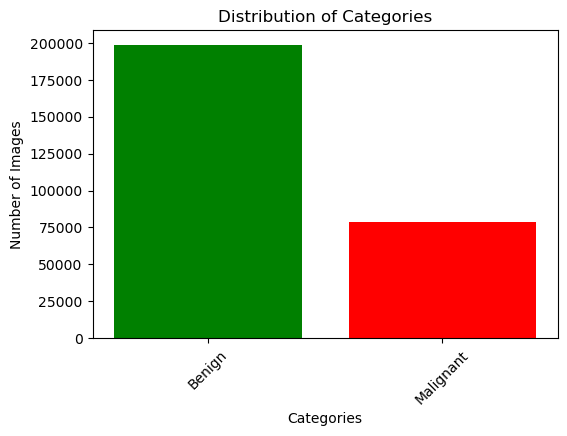

In [168]:
categories = ['Benign', 'Malignant']
category_counts = [label_counts[0], label_counts[1]]

plt.figure(figsize= (6, 4))
plt.bar(categories, category_counts, color= ['green', 'red'])
plt.title('Distribution of Categories')
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.xticks(rotation= 45)
plt.show()

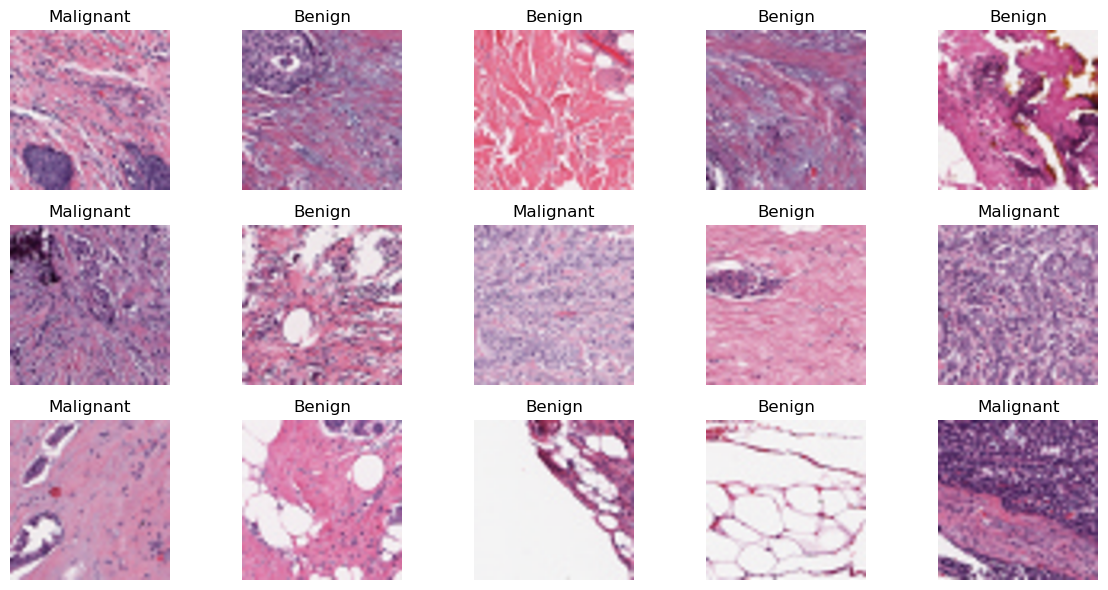

In [169]:
fig, axes = plt.subplots(3, 5, figsize= (12, 6))

axes = axes.flatten()

for i in range(15):
    idx = random.randint(0, len(data) - 1)
    img, label = data[idx]

    img = img.resize((224, 224)) if isinstance(img, Image.Image) else transforms.ToPILImage()(img)
    
    axes[i].imshow(img)
    axes[i].set_title('Benign' if label == 0 else 'Malignant')
    axes[i].axis('off') 

plt.tight_layout()
plt.show()

In [170]:
# Check imbalance ratio
benign = label_counts[0]
malignant = label_counts[1]

imbalance_ratio = benign / malignant if benign > malignant else malignant / benign
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("The dataset is imbalanced.")
else:
    print("The dataset is balanced.")

Imbalance Ratio: 2.52
The dataset is imbalanced.


In [172]:
# Weighted Loss

# Class Weights
total = benign + malignant

weight_benign = total / (2 * benign)
weight_malignant = total / (2 * malignant)

class_weights = torch.tensor([weight_benign, weight_malignant], dtype= torch.float)

print(f"Class Weights: {class_weights}")

Class Weights: tensor([0.6982, 1.7613])


In [173]:
# GPU Check
if torch.backends.mps.is_available():
    print("Using MPS backend for MacOS.")
else:
    print("Using CPU backend.")

Using MPS backend for MacOS.


In [174]:
# Device Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 3. Models

In [175]:
# CNN Architecture
class HistopathologyCNN(nn.Module):
    def __init__(self):
        super(HistopathologyCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)     
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.4)
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x
        


In [176]:
# Model initialization

model = HistopathologyCNN().to(device)

In [177]:
# Loss Function

criterion = nn.CrossEntropyLoss(weight= class_weights).to(device)


In [178]:
# Optimizer

optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

In [179]:
# Scheduler

scheduler = ReduceLROnPlateau(optimizer, mode= 'min', factor= 0.5, patience= 3, verbose= True)

/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# 4. Training and Validation


In [182]:
num_epochs = 50
train_losses, validation_losses = [], []
train_accuracies, validation_accuracies = [], []

for epoch in range(num_epochs):
    start_time = time.time()

    # Training 
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct / total

    # Validation
    model.eval()
    validation_running_loss, validation_correct, validation_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            validation_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            validation_correct += (predicted == labels).sum().item()
            validation_total += labels.size(0)

    validation_loss = validation_running_loss / validation_total
    validation_accuracy = validation_correct / validation_total

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)

    # Scheduler step
    scheduler.step(validation_loss)

    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch + 1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}  |  Train Accuracy: {train_accuracy:.4f}  |  "
          f"Validation Loss: {validation_loss:.4f}  |  Validation Accuracy: {validation_accuracy:.4f}  |  "
          f"Time: {elapsed_time:.2f} seconds")



Epoch [1/50], Train Loss: 0.3948  |  Train Accuracy: 0.8282  |  Validation Loss: 0.3711  |  Validation Accuracy: 0.8394  |  Time: 776.79 seconds
Epoch [2/50], Train Loss: 0.3671  |  Train Accuracy: 0.8398  |  Validation Loss: 0.4373  |  Validation Accuracy: 0.8586  |  Time: 773.33 seconds
Epoch [3/50], Train Loss: 0.3522  |  Train Accuracy: 0.8470  |  Validation Loss: 0.3627  |  Validation Accuracy: 0.8478  |  Time: 777.16 seconds
Epoch [4/50], Train Loss: 0.3412  |  Train Accuracy: 0.8527  |  Validation Loss: 0.3497  |  Validation Accuracy: 0.8680  |  Time: 773.93 seconds
Epoch [5/50], Train Loss: 0.3312  |  Train Accuracy: 0.8592  |  Validation Loss: 0.3305  |  Validation Accuracy: 0.8464  |  Time: 774.84 seconds
Epoch [6/50], Train Loss: 0.3206  |  Train Accuracy: 0.8646  |  Validation Loss: 0.3308  |  Validation Accuracy: 0.8783  |  Time: 779.93 seconds
Epoch [7/50], Train Loss: 0.3137  |  Train Accuracy: 0.8686  |  Validation Loss: 0.2977  |  Validation Accuracy: 0.8724  |  Time: 

# 5. Improve with Transfer Learning
- Load a pre-trained model (ResNet50 , EfficientNetB0).

- Fine-tune it on your dataset.

- Compare the results with your simple CNN.